Lab 1. Fake news detection (binary classification)

In [300]:
import pandas as pd

df = pd.read_csv('/Users/e.baronov/Programming/Materials/laboratory works/lab_1/fake_or_real_news.csv')
df.head(1)

Unnamed: 0                         title  \
0        8476  You Can Smell Hillary’s Fear   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

# 1. EDA

## Dataset overview: check size, number of classes, balance, average text length.

In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


In [302]:
# size
df.shape

(6335, 4)

In [303]:
# number of classes and balance
df['label'].value_counts()

label
REAL    3171
FAKE    3164
Name: count, dtype: int64

In [304]:
# proportion
df['label'].value_counts(normalize=True)
df['label'].value_counts(normalize=True)

label
REAL    0.500552
FAKE    0.499448
Name: proportion, dtype: float64

У нас действительно два лейбла с практически идеальным распределением.

In [305]:
# Check average text length, average word length and average symbols count
def avg_statistics(series: pd.Series):
    series_name = series.name
    awc = series.str.split().str.len().mean()
    asl = series.str.len().mean()
    awl = (asl - awc + 1) / awc

    return (
        (f'average words count in {series_name}', awc),
        (f'average symbols count in {series_name}', asl),
        (f'average words length in {series_name}', awl)
    )

In [306]:
avg_statistics(df['title'])

(('average words count in title', np.float64(10.496448303078138)),
 ('average symbols count in title', np.float64(65.2776637726914)),
 ('average words length in title', np.float64(5.314294307842695)))

In [307]:
avg_statistics(df['text'])


(('average words count in text', np.float64(776.3007103393844)),
 ('average symbols count in text', np.float64(4707.250355169692)),
 ('average words length in text', np.float64(5.064982670325436)))

Может быть, есть смысл сравнить эти показатели у разных маркировок

In [308]:
fake_df = df[df['label'] == 'FAKE'].drop('label', axis=1)
real_df = df[df['label'] == 'REAL'].drop('label', axis=1)

fake_title_st = avg_statistics(fake_df['title'])
fake_text_st = avg_statistics(fake_df['text'])
real_title_st = avg_statistics(real_df['title'])
real_text_st = avg_statistics(real_df['text'])

In [309]:
import pandas as pd

df_fr = pd.DataFrame(index=[fake_title_st[i][0] for i in range(3)] +
                           [fake_text_st[i][0] for i in range(3)],
                     columns=['fake', 'real'])

for ft, rt in zip(fake_title_st, real_title_st):
    df_fr.loc[ft[0], 'fake'] = round(float(ft[1]), 2)
    df_fr.loc[rt[0], 'real'] = round(float(rt[1]), 2)

for ft, rt in zip(fake_text_st, real_text_st):
    df_fr.loc[ft[0], 'fake'] = round(float(ft[1]), 2)
    df_fr.loc[rt[0], 'real'] = round(float(rt[1]), 2)

print(df_fr)

                                   fake     real
average words count in title      11.13     9.86
average symbols count in title    69.18    61.38
average words length in title       5.3     5.33
average words count in text      679.13   873.26
average symbols count in text   4121.05  5292.16
average words length in text       5.07     5.06


In [310]:
words_title_diff = ((11.13 - 9.86) / 9.86) * 100
symbols_title_diff = ((69.18 - 61.38) / 61.38) * 100
wordlen_title_diff = ((5.3 - 5.33) / 5.33) * 100

words_text_diff = ((679.13 - 873.26) / 873.26) * 100
symbols_text_diff = ((4121.05 - 5292.16) / 5292.16) * 100
wordlen_text_diff = ((5.07 - 5.06) / 5.06) * 100

In [311]:
print(words_title_diff)
print(symbols_title_diff)
print(wordlen_title_diff)
print(words_text_diff)
print(symbols_text_diff)
print(wordlen_text_diff)

12.880324543610563
12.707722385141745
-0.5628517823639821
-22.230492636786295
-22.129149534405606
0.19762845849803706


При практически одинаковой длине слова мы видим разницу в 12 % между количеством слов и символов, где у fake больше, при этом есть разница около 22% у количества слов и символов, где у real больше. (Отсюда можем поставить гипотезу, что фейковые новости в среднем содержат больше информации для привлечения внимания, а также гипотезу, что настоящие новости соддержат больше деталей, фактов и некоторого контекста.)

## Inspect text quality: manually inspect a random sample of texts from each class. Write down your observations.

In [312]:
pd.set_option('display.max_colwidth', None)
fake_df.sample(10, random_state = 5)
#pd.reset_option('display.max_colwidth')

Unnamed: 0  \
4243        7799   
6257        9325   
3529        7650   
3107        7208   
3659        9972   
5488        7923   
592         8577   
5578        6023   
5446        9298   
4842        7184   

                                                                                     title  \
4243                                         Comment on Useful Idiots for Islam by MomOfIV   
6257  As Flint Suffers, Nestlé Plans Dramatic Expansion of Water Privatization in Michigan   
3529                                                  Key Time In Collective Human History   
3107          Bill Clinton Inc: Billions for the Foundation, $116 Million for the Clintons   
3659            Madman Merkel Demands the Internet Publicly Release All Closed-Source Code   
5488           Look out, Paul Ryan! Masochist Paul Nehlen is gunning for House speakership   
592               ‘A noun, a verb and Donald Trump’: Rubio seeks to seize on Murphy’s flaw   
5578                                                    Football Follies 2016: NCAA Week 9   
5446           Cyrus Mistry joins AAP; Tata Sons shortlists candidates for chairman’s post   
4842                                BLACK TRUMP SUPPORTERS call Hillary Clinton a “racist”   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

Так смотреть неудобно, взглянем на несколько примеров другим способом

In [313]:
random_fake_row = fake_df.sample(1, random_state=5) # random_state= 5, 6, 42, 1024
random_fake_row

,Unnamed: 0,title,text
4243,7799,Comment on Useful Idiots for Islam by MomOfIV,"| January 15, 2016 at 6:00 am | Reply \nSlavery still exists in Saudi Arabia (as well as parts of Africa) today. But what is Saudi Arabia? For all practical purposes, it is Great Britain’s vassal state, run by a family of criminals whom we and Great Britain protect. Saudi Arabia is not even a nation-state in the modern sense of the term: The Royal Family there considers themselves to be owners of the land—as if it were their personal property—who allow others to live on it. (Churchill and others either set up Saudi Arabia or allowed it to become established in its current political structure. They also established the current national boundaries in the Middle East, leading, in part, to the present troubles). What kind of a religion is this that encourages all of the worst carnality of men? St. Thomas Aquinas tackled this matter head-on: He wrote that Mohammed sought out men as carnal as himself, and he encouraged his followers to do the same. (And they consider Jesus Our Lord to be a prophet, as if He would EVER condone their evil?!) Islam, like the New World Order manipulating it, is a BEAST SYSTEM. It is a criminal racket with a political ideology and structure, masquerading as a religion! WAKE UP, PEOPLE!"


In [314]:
print(f"Заголовок:")
print(random_fake_row['title'])
print(f"\nТекст:")
print(random_fake_row['text'])

Заголовок:
4243    Comment on Useful Idiots for Islam by MomOfIV
Name: title, dtype: object

Текст:
4243    | January 15, 2016 at 6:00 am | Reply \nSlavery still exists in Saudi Arabia (as well as parts of Africa) today. But what is Saudi Arabia? For all practical purposes, it is Great Britain’s vassal state, run by a family of criminals whom we and Great Britain protect. Saudi Arabia is not even a nation-state in the modern sense of the term: The Royal Family there considers themselves to be owners of the land—as if it were their personal property—who allow others to live on it. (Churchill and others either set up Saudi Arabia or allowed it to become established in its current political structure. They also established the current national boundaries in the Middle East, leading, in part, to the present troubles). What kind of a religion is this that encourages all of the worst carnality of men? St. Thomas Aquinas tackled this matter head-on: He wrote that Mohammed sought out men as ca

В фейковых новостях повышенное количество слов, написанных капсом, возможно это может быть важно при определении лейбла

* it, is a BEAST SYSTEM. It is a criminal racket with a political ideology and structure, masquerading as a religion! WAKE UP, PEOPLE!
* PLEASE SUBSCRIBE TO OUR YOUTUBE CHANNEL AND DON’T FORGET TO “LIKE” US
* IF HILLARY CLINTON IS CHARGED WITH OBSTRUCTION OF JUSTICE SHE COULD GO TO PRISON FOR 20 YEARS - в тч некоторые заголовки

In [315]:
random_real_row = real_df.sample(1, random_state=5) # random_state= 5, 6, 42, 1024
random_real_row

Unnamed: 0                                                  title  \
5407        4969  Donald Trump and the $12.7 million Ukraine connection   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [316]:
print(f"Заголовок:")
print(random_real_row['title'])
print(f"\nТекст:")
print(random_real_row['text'])

Заголовок:
5407    Donald Trump and the $12.7 million Ukraine connection
Name: title, dtype: object

Текст:
5407    Donald Trump’s campaign manager, Paul Manafort, is linked to an undisclosed $12.7 million in campaign contributions from his previous work as political consultant.\n\nRepublican presidential nominee Donald Trump gives a thumbs up as his campaign manager Paul Manafort (c.) and daughter Ivanka (r.) look on during Mr. Trump's walk through at the Republican National Convention in Cleveland, July 21, 2016.\n\nFollowing the recent alleged infiltration of the Democratic National Committee servers by Russian hackers, as well as the then ensuing though now-redacted statement by Donald Trump that Russian hackers should help find Hillary Clinton’s missing emails, has raised questions about the Republican presidential nominee and his relationship with Russia.\n\nThose questions are now further complicated by the revelation of a secret ledger that allegedly connects Mr. Trump's campai

* В настоящих новостях наблюдаем другой шрифт и слова другого цвета - не факт что этого нет в фейковых новостях

![image.png](attachment:c6a2fedb-5407-4ff8-beff-633f0b46eb64.png)

* Много конкретных чисел, дат, цитат, процентов

* Также есть слова написанные капсом - EXCLUSIVE, но их не так много

![image.png](attachment:da2970d6-120e-4798-b981-97eb3590252e.png)

* Есть много видов символов помимо цифр, букв и знаков препинания, нужно посмотреть строчки, где они содержатся***

* !!! нужно ли убирать плохие знаки и знаки препинания вообще? !!!

## Quantitative Checks: check the number of duplicates, missing values. Plot a histogram of text lengths.

In [317]:
df.isnull().sum()

Unnamed: 0    0
title         0
text          0
label         0
dtype: int64

In [318]:
print(df['text'].str.strip().eq('').sum())
print(df['title'].str.strip().eq('').sum())

36
0


Формально пропущенных значений нет, но в данных есть новости, у которых не заполнен текст. Это повлияет на количество дубликатов, поэтому временно удалим их

In [319]:
print(df['Unnamed: 0'].duplicated().sum())
print(df['title'].duplicated().sum())
print(df[df['text'].str.strip() != '']['text'].duplicated().sum())
print(df[df['text'].str.strip() != ''].duplicated(['title', 'text']).sum())

0
79
240
29


Также интересно посмотреть, есть ли дубликаты с разными лейблами

In [320]:
print(df.duplicated(['title', 'label']).sum())
print(df[df['text'].str.strip() != ''].duplicated(['text', 'label']).sum())
print(df[df['text'].str.strip() != ''].duplicated(['title', 'text', 'label']).sum())
# Количество не уменьшилось, поэтому у одинаковых текстов и заголовков одинаковые лейблы

79
240
29


In [321]:
print(df['Unnamed: 0'].min())
print(df['Unnamed: 0'].max())

2
10557


Столбец 'Unnamed: 0' не содержит дубликаты, при этом отсортированный ряд не будет представлять собой порядковые числа. Непонятно зачем этот столбец нужен сейчас или был нужен раньше. Возможно этот датасет - сэмпл из какого-то большего датасета.

! Поскольку в нашем датасете средняя длина слова одинаковая - 5.3 и 5.33, то мы можем анализировать длину текста исходя из количества слов в этих текстах, это будет проще для восприятия и анализа

In [322]:
df_text_words_count = df['text'].str.split().str.len()

In [323]:
df_text_words_count.describe()

count     6335.000000
mean       776.300710
std        854.333358
min          0.000000
25%        289.000000
50%        597.000000
75%       1024.000000
max      20891.000000
Name: text, dtype: float64

In [324]:
import matplotlib.pyplot as plt

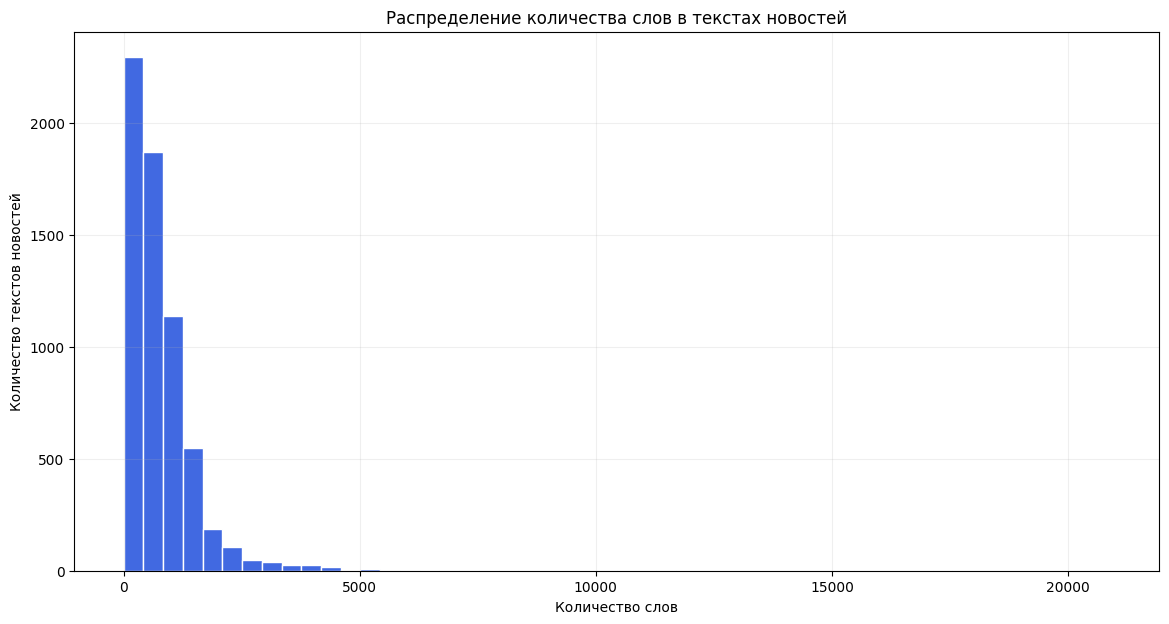

In [325]:
plt.figure(figsize=(14, 7))

plt.hist(
    df_text_words_count,
    bins=50,
    color='royalblue',
    edgecolor='white'
)

plt.title(f'Распределение количества слов в текстах новостей')
plt.xlabel('Количество слов')
plt.ylabel('Количество текстов новостей')
plt.grid(True, alpha=0.2)

0 - это пустые значения, а также видим, что есть выбросы в районе 15000 - 20000, уберем их для лучшего отображения, а заодно графически покажем некоторую статистику

In [326]:
def hist_count_words(df_words_count, name):
    upper_limit = df_words_count.quantile(0.99)
    filtered_counts = df_words_count[df_words_count <= upper_limit]
    filtered_counts = filtered_counts[filtered_counts != 0]

    plt.figure(figsize=(14, 7))

    plt.hist(
        filtered_counts,
        bins=50,
        color='royalblue',
        edgecolor='white'
    )

    plt.title(f'Распределение количества слов в {name} новостей')
    plt.xlabel('Количество слов')
    plt.ylabel(f'Количество {name} новостей')
    plt.grid(True, alpha=0.2)

    median_val = filtered_counts.median()
    mean_val = filtered_counts.mean()

    plt.axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Медиана: {int(median_val)}')
    plt.axvline(mean_val, color='green', linestyle='-.', linewidth=2, label=f'Среднее: {int(mean_val)}')
    for percentile in [25, 75, 90]:
        value = filtered_counts.quantile(percentile/100)
        plt.axvline(value, color='purple', linestyle=':', linewidth=1.5, alpha=0.7, label=f'{percentile}%: {int(value)}')

    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

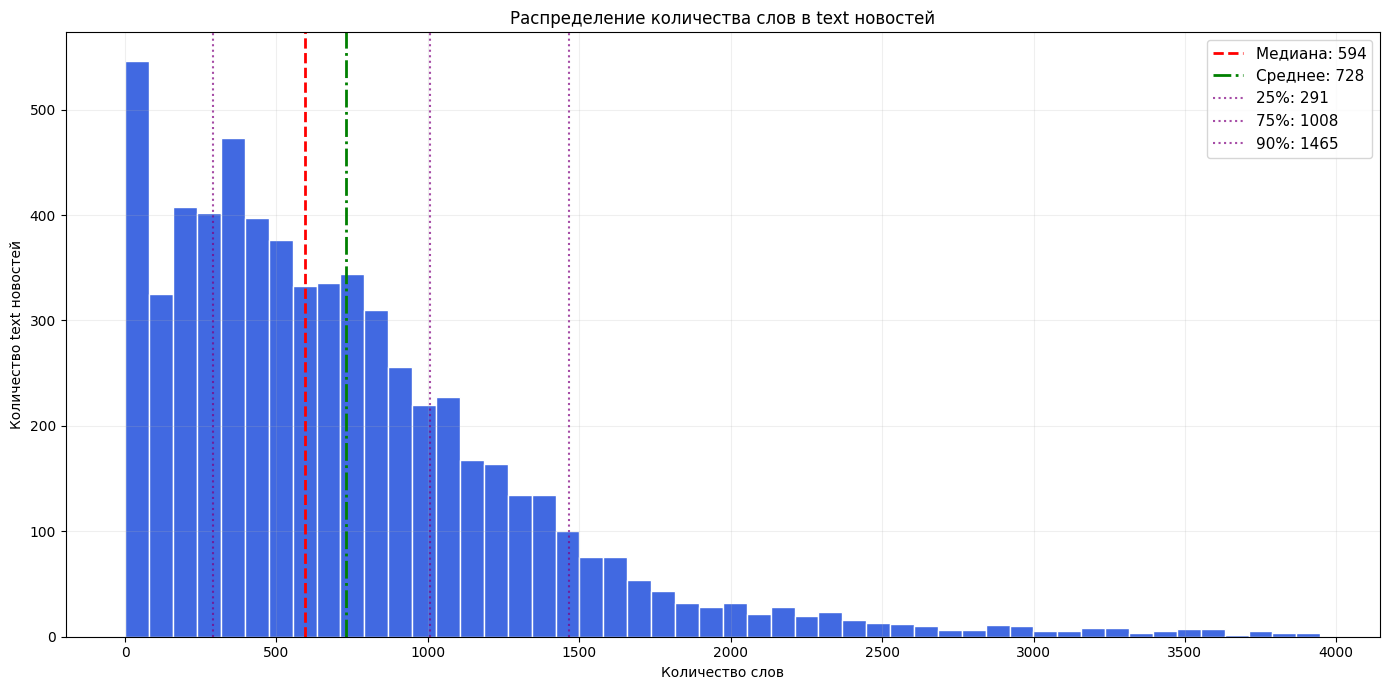

In [327]:
hist_count_words(df['text'].str.split().str.len(), 'text') # text в df

Распределение скошено вправо, двумодальное (чаще всего в новостях меньше 100 или около 400 слов). Основная масса новостей имеет количество слов в промежутке 291 - 1008 слов. В среднем новость содержит 728 слов, однако медиана равна 594 из-за скошенности распределения.


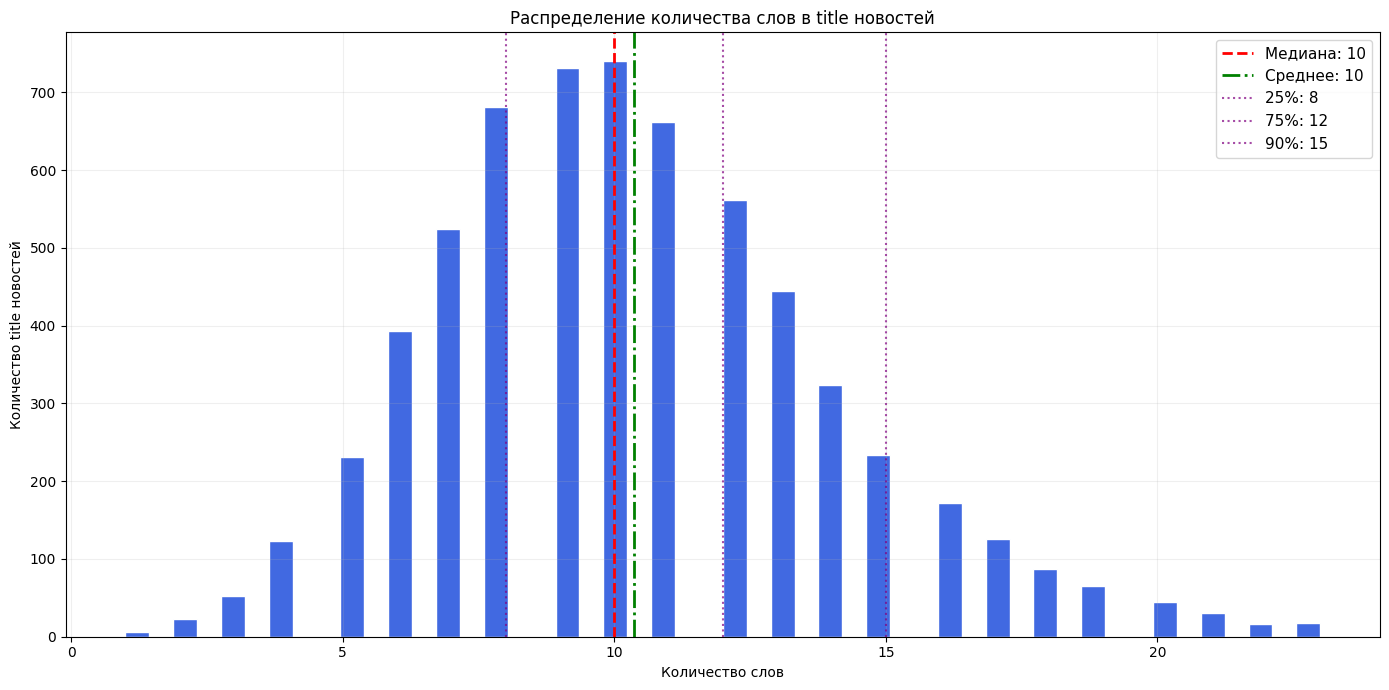

In [328]:
hist_count_words(df['title'].str.split().str.len(), 'title') # title в df

Распределение скошено вправо, унимодальное (чаще всего в заголовках 10 слов). Основная масса заголовков имеет количество слов в промежутке 8-12 слов. Медиана, мода и среднее значение обьединяются на 10 словах, если округлить.



Также быстро взглянем отдельно на распределение fake и real, посмотрим на их различия

text

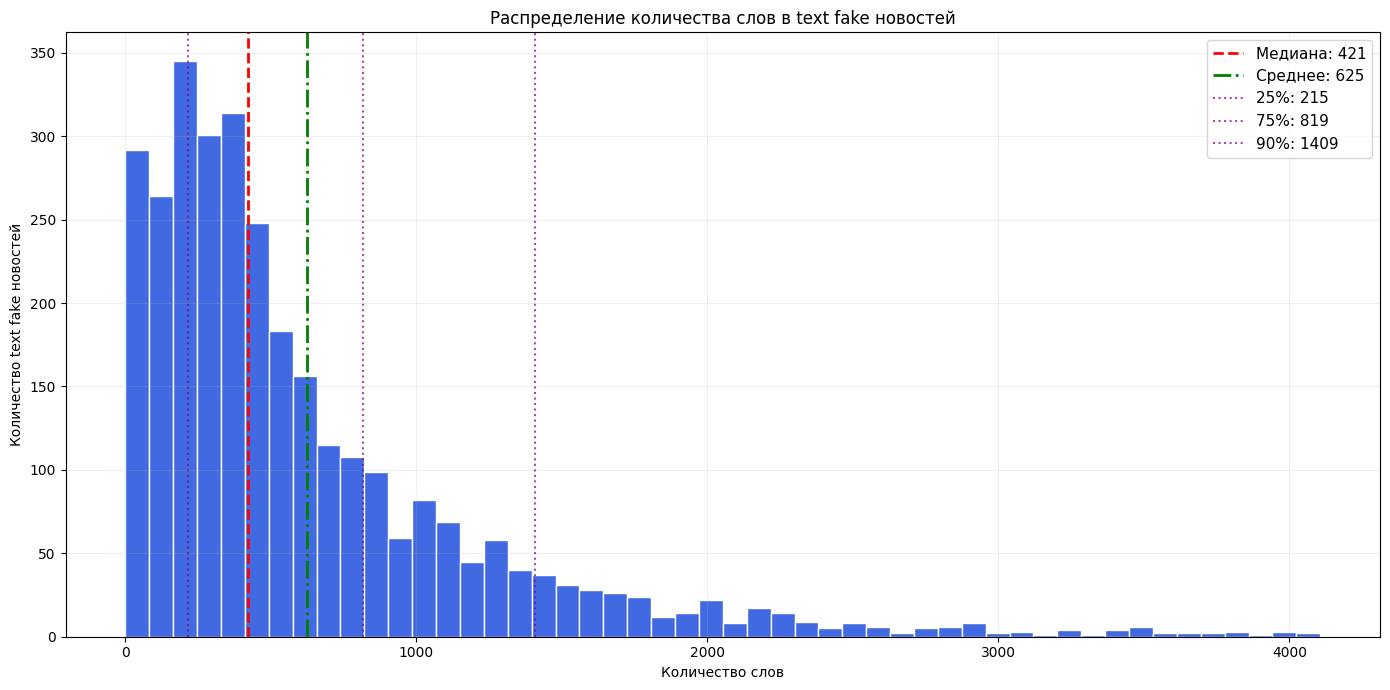

In [329]:
hist_count_words(fake_df['text'].str.split().str.len(), 'text fake') # text в fake_df

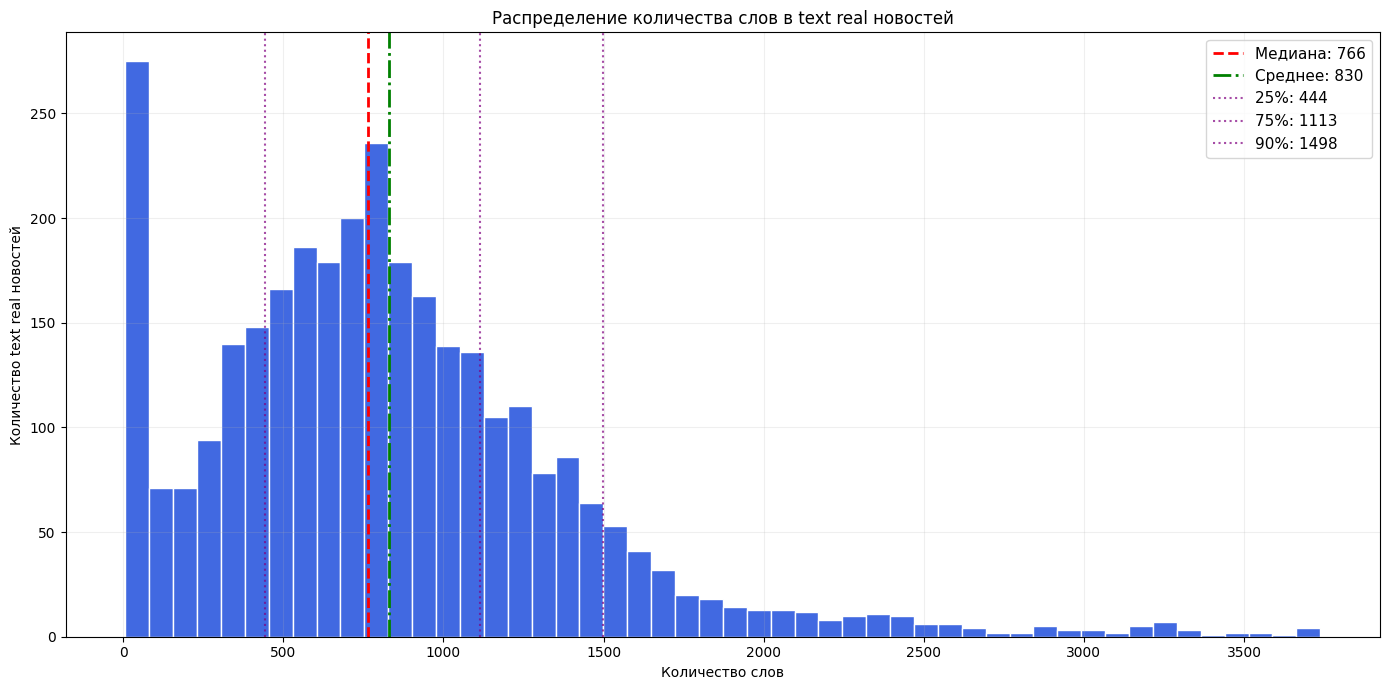

In [330]:
hist_count_words(real_df['text'].str.split().str.len(), 'text real') # text в real_df

У настоящих новостей заметно больше слов (а соответственно и длина текста), чем у фейковых, однако к 90 перцентилю значения немного сближаются, это значит, что длину текста можно использовать как один из критериев для классификации правдоподобности, однако если слов больше чем 2000, определить правдоподобность новости по этому критерию тяжелее. Опять же видим, что среднее и медиана у настоящих новостей заметно выше.

title

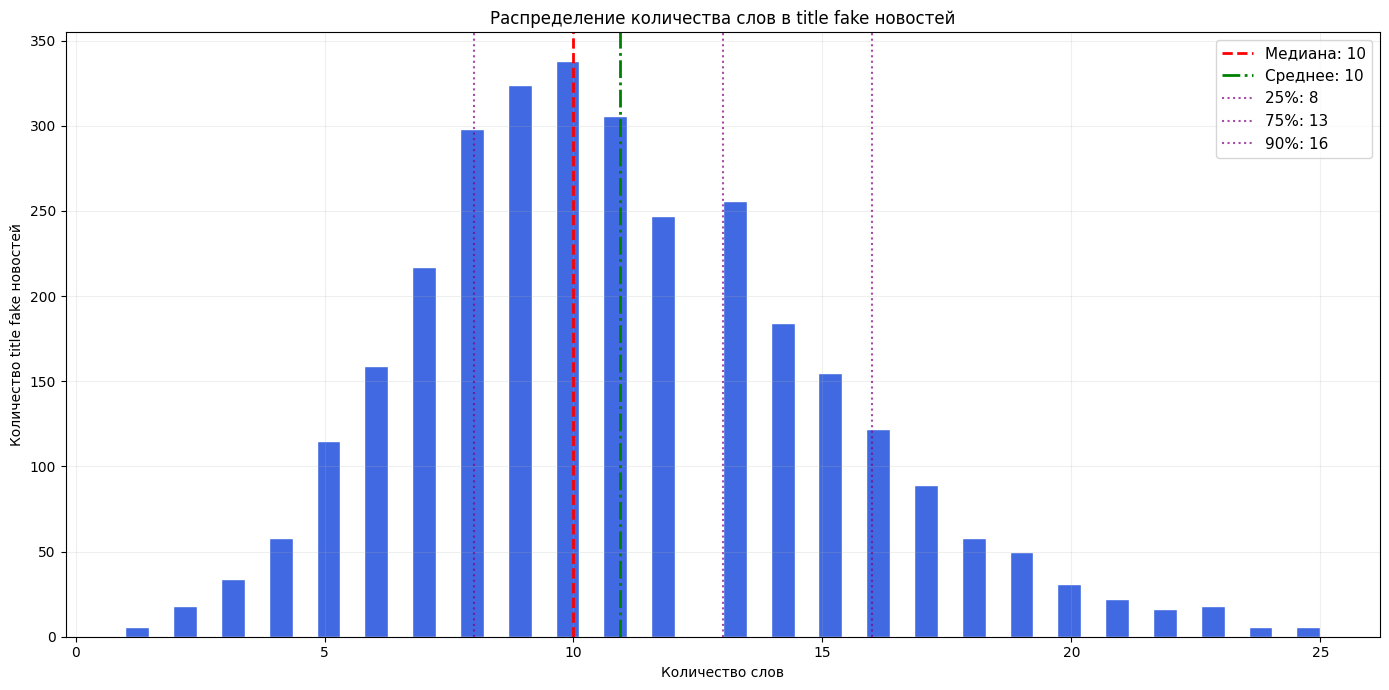

In [331]:
hist_count_words(fake_df['title'].str.split().str.len(), 'title fake') # title в fake_df

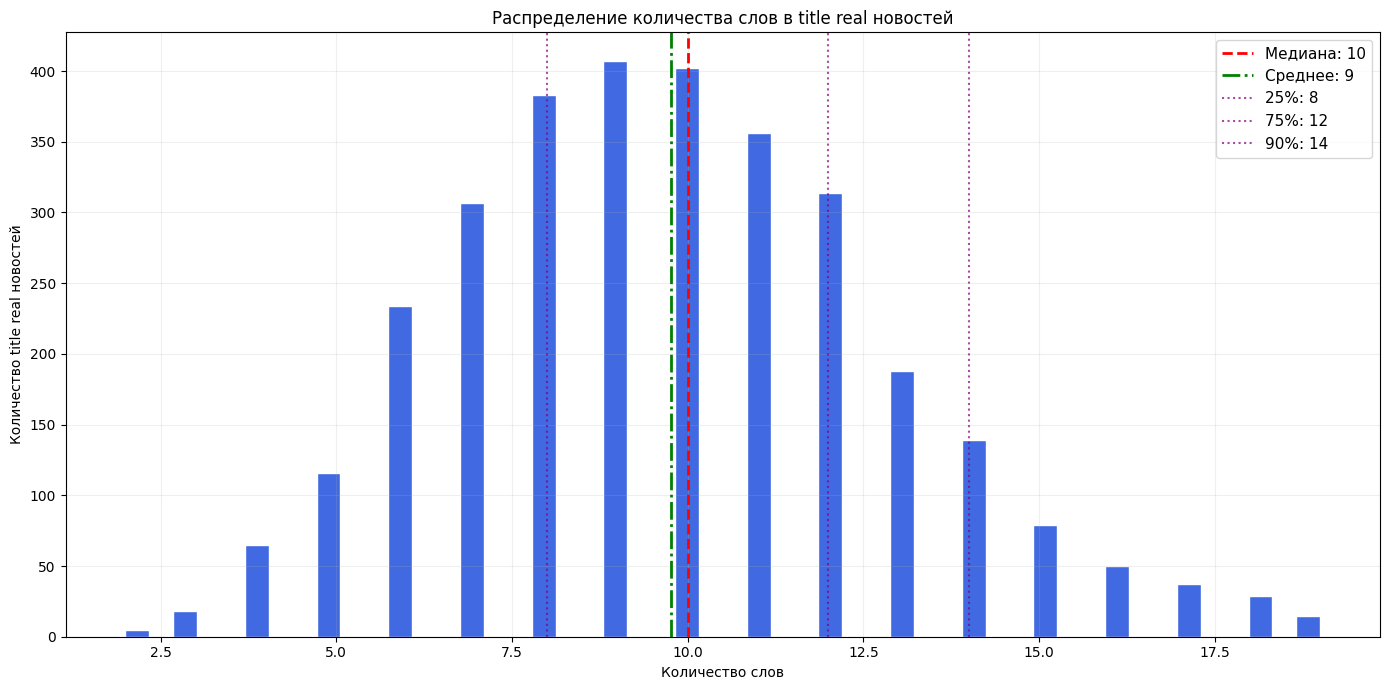

In [332]:
hist_count_words(real_df['title'].str.split().str.len(), 'title real') # title в real_df

У фейковых новостей распределение двумодальное, у настоящих - унимодальное, в остальном распределения схожи по среднему, медиане, а также по 25, 75, 90 перцентилю. Однако, важно отметить, что фейковые новости будут иметь более широкий разброс вправо, что значит более вероятное появление фейковой новости, если количество слов больше 19

# Preprocessing

## Fix any problems you’ve found during EDA step

In [333]:
df_pr = df.copy(deep=True)

### Проблема 1 - пустые тексты в датасете

In [334]:
empty_text_df = df[df['text'].str.strip() == '']
empty_text_df

,Unnamed: 0,title,text,label
106,5530,"The Arcturian Group by Marilyn Raffaele October 23, 2016 [VIDEO]",,FAKE
710,8332,MARKETWATCH LEFTIST: MSM’s “Blatant” Anti Trump Bias May Be Suicidal,,FAKE
806,9314,Southern Poverty Law Center Targets Anti-Jihad Crusaders (Ann Corcoran Honored!),,FAKE
919,10304,Refugee Resettlement Watch: Swept Away In North Carolina,,FAKE
940,9474,Michael Bloomberg Names Technological Unemployment as the Next Administration’s “Greatest Conundrum”,,FAKE
1664,5802,Alert News : Putins Army Is Coming For World War3 Against Obama year 2016 New Video!!!,,FAKE
1736,9564,"An LDS Reader Takes A Look At Trump Accuser Jessica Drake, Concludes His Leaders Are “Latter-Day Sissies",,FAKE
1851,5752,America’s Senator Jeff Sessions Warns of Worsening Pre-Election Border Anarchy,,FAKE
1883,8816,Paris Migrant Campers Increase after Calais Is Shut,,FAKE
1941,7525,Putins Army is coming for World war 3 against Obama year 2016!!! New Video!!! Kopya,,FAKE


In [335]:
empty_text_df.shape

(36, 4)

Все новости с пустыми текстами помечены как fake. Предполагается, что новость должна содержать в себе как заголовок, так и содержание - текст, а также классификация должна основываться на анализе заголовка и содержания, текст для нее критически важен, поэтому будет нерелевантно оставлять новости - пустые строки.

In [336]:
# Удаляем строки, где text не содержит текст
df_pr = df_pr[df_pr['text'].str.strip() != '']
df_pr.shape

(6299, 4)

### Проблема 2 - дубликаты

Полные дубликаты - и заголовок и текст нам точно не нужны, удаляем сразу, они могут помешать обучению и проверке модели

In [337]:
df_pr = df_pr.drop_duplicates(subset=['title', 'text'])
df_pr.shape

(6270, 4)

In [338]:
duplicate_texts = df_pr[df_pr['text'].duplicated(keep=False)]
duplicate_texts['title'].value_counts().head()

title
Cruz's immigration gambit                                             2
Strong Solar Storm, Tech Risks Today | S0 News Oct.26.2016 [VIDEO]    1
2016 cash race: It's on                                               1
White House facing rocky legal road on immigration                    1
Sabotaging Common Core                                                1
Name: count, dtype: int64

In [339]:
import random

In [340]:
random.sample(list(duplicate_texts.groupby('text')), 1) # try several times and compare titles and texts

[('Trump Raises Concern Over Members Of Urban Communities Voting More Than Zero Times ATKINSON, NH—Warning supporters that the troubling practice could affect the outcome of the election, Republican presidential nominee Donald Trump expressed strong concern Friday that members of urban communities were voting more than zero times, sources reported. Nation Puts 2016 Election Into Perspective By Reminding Itself Some Species Of Sea Turtles Get Eaten By Birds Just Seconds After They Hatch WASHINGTON—Saying they felt anxious and overwhelmed just days before heading to the polls to decide a historically fraught presidential race, Americans throughout the country reportedly took a moment Thursday to put the 2016 election into perspective by reminding themselves that some species of sea turtles are eaten by birds just seconds after they hatch. Report: Election Day Most Americans’ Only Time In 2016 Being In Same Room With Person Supporting Other Candidate WASHINGTON—According to a report relea

In [341]:
random.sample(list(duplicate_texts.groupby('title')), 1) # try several times and compare titles and texts


[('BREAKING: Obama Says There Were No Scandals During His Administration! HAHAHA!',
        Unnamed: 0  \
  3730        7843   
  
                                                                                 title  \
  3730  BREAKING: Obama Says There Were No Scandals During His Administration! HAHAHA!   
  
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

Дубликаты новостей с одинаковыми текстами и с одинаковыми заголовками можно удалять, так как они могут искуственно завысить точность модели, в том числе это действительно дубликаты - вторая часть новости обычно либо перефразирована, либо не содержит смысла.

In [342]:
df_pr = df_pr.drop_duplicates(subset=['text'])
df_pr = df_pr.drop_duplicates(subset=['title'])
df_pr.shape

(6010, 4)

### Проблема 3 - Лишний столбец

In [343]:
df_pr = df_pr.drop('Unnamed: 0', axis=1) # Удаляем, так как не несет никакой смысловой нагрузки
df_pr.shape

(6010, 3)

### Проблема 4 - Выбросы

Удалим выбросы

In [344]:
upper_limit = df_pr['text'].str.split().str.len().quantile(0.99)
df_pr = df_pr[df_pr['text'].str.split().str.len() <= upper_limit]
df_pr.shape

(5949, 3)

## Apply any data transformations you find suitable (punctuation removal, stemming/lemmatization, etc.)

In [345]:
from tqdm.auto import tqdm
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re

import nltk
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
tqdm.pandas()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/e.baronov/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/e.baronov/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/e.baronov/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [346]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [347]:
def clean_text(text):
    cleaned = re.sub(r'[^\w\s.,!?;:\'\"-]', ' ', str(text))
    cleaned = re.sub(r'\s+', ' ', cleaned)
    cleaned =cleaned.strip()

    word_tokens = word_tokenize(cleaned)

    filtered_tokens = [w for w in word_tokens if w.lower() not in stop_words]

    pr_tokens = []
    for word in filtered_tokens:
        if word.isupper() and len(word) > 1:
            pr_tokens.append(word)
        else:
            pr_tokens.append(word.lower())

    filtered_tokens = [lemmatizer.lemmatize(word) for word in pr_tokens]
    res_text = ' '.join(filtered_tokens)

    return res_text

In [348]:
df_pr['text'] = df_pr['text'].progress_apply(clean_text)
df_pr['title'] = df_pr['title'].progress_apply(clean_text)
df_pr.head(1)

100%|██████████| 5949/5949 [00:00<00:00, 22796.78it/s]


title  \
0  smell hillary fear   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

Оставляю знаки препинания, а также оставляю слова написанные капсом, так как считаю, что это может быть важно при классификации правдоподобности новостей. В тексте были значки и ненужные невалидные символы, поэтому оставляем буквы, числа, знаки препинания и пробелы, а остальные символы удаляем.

# Vectorization

## Apply the following vectorization techniques: TF-IDF, Word2Vec, FastText.

In [349]:
from gensim.models import Word2Vec, FastText
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

import warnings
warnings.filterwarnings('ignore')

Для "text":

In [350]:
# TF-IDF
tfidf_vectorizer = TfidfVectorizer()

tfidf = tfidf_vectorizer.fit_transform(df_pr['text'])

In [351]:
def tokenize(text):
    tokenized_text = word_tokenize(text)
    return tokenized_text

In [352]:
tokenized_text = df_pr['text'].apply(tokenize)

In [353]:
# Word2Vec
w2v_model = Word2Vec(
    sentences=tokenized_text,
    vector_size=600,
    workers=18,
    sg=1,
    epochs=50,
    seed=42
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

In [354]:
def write_w2v_vector(tokens):
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(600)

w2v_vectors = np.array([write_w2v_vector(tokens) for tokens in tokenized_text])

In [355]:
w2v_model.save("word2vec_lab_1.1.1.model")

In [220]:
# FastText
ft_model = FastText(
    sentences=tokenized_text,
    vector_size=300,
    workers=14,
    sg=1,
    epochs=10,
    seed=42,
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

In [221]:
ft_vectors = np.array([np.mean([ft_model.wv[word] for word in words], axis=0) for words in tokenized_text])

In [222]:
ft_model.save("fasttext_lab_1.1.model")

In [356]:
w2v_model.wv['trump']

array([-0.04629502, -0.03279341,  0.01564431, -0.06424691,  0.02568537,
       -0.17915873, -0.03934277,  0.06257094, -0.15808788,  0.06894801,
        0.0802981 ,  0.0250122 , -0.16706485, -0.08067075,  0.13967785,
       -0.0499412 ,  0.11337285, -0.26477447, -0.11858705, -0.26915747,
        0.07770701,  0.02715801, -0.02666599,  0.12788138,  0.1434683 ,
        0.16403098, -0.01522534,  0.05816382,  0.09829208,  0.1445295 ,
       -0.00132915,  0.07324522, -0.11598676, -0.11661143, -0.0558033 ,
       -0.03451256,  0.18090706,  0.00761346,  0.10885174,  0.10333519,
       -0.05605329,  0.22343117,  0.07613982,  0.1856793 ,  0.0604073 ,
        0.00918438,  0.02706977,  0.16413863,  0.01606287,  0.15097757,
       -0.11254766,  0.03530797, -0.03808288, -0.02703029, -0.02900496,
        0.08924067, -0.008734  ,  0.02339108,  0.0250365 ,  0.23316507,
        0.08331338, -0.14159654, -0.06678216,  0.10343622, -0.03629914,
       -0.07701726,  0.05119486,  0.05243789,  0.04735298,  0.07

In [224]:
ft_model.wv['trump']

array([ 0.07985684,  0.13959813,  0.06168567, -0.33725694,  0.2599294 ,
       -0.30875394, -0.30774826, -0.14228572,  0.15253131, -0.1921571 ,
       -0.04508943,  0.27703628, -0.07645524, -0.03120266,  0.12329431,
        0.10703643, -0.03217405, -0.1023706 ,  0.18980026,  0.13673064,
       -0.04325758, -0.3173207 , -0.2440735 ,  0.20235048,  0.25414196,
        0.13627137,  0.10620438, -0.0972181 , -0.19761762,  0.04432791,
        0.02868718, -0.14618078, -0.18771693, -0.4740736 ,  0.16611263,
        0.0333116 ,  0.02027548,  0.13648555,  0.2562817 ,  0.0525919 ,
        0.14958525, -0.04502977, -0.08043192, -0.13815744, -0.02205932,
       -0.09743122,  0.02799475, -0.29290158,  0.16105436,  0.07986502,
        0.2820521 ,  0.12821014,  0.225977  , -0.10645304, -0.00636187,
       -0.22700527,  0.12132464,  0.03649377, -0.06483764, -0.08315299,
        0.01442526,  0.5249646 , -0.10393413,  0.26699877, -0.12319891,
       -0.08915964,  0.01111838,  0.06554697, -0.15125205,  0.18

## Apply a PCA method to your vectors. Visualize and explore the vectors you’ve got. Make comparisons. Choose one vector type for experiments and explain your choice.

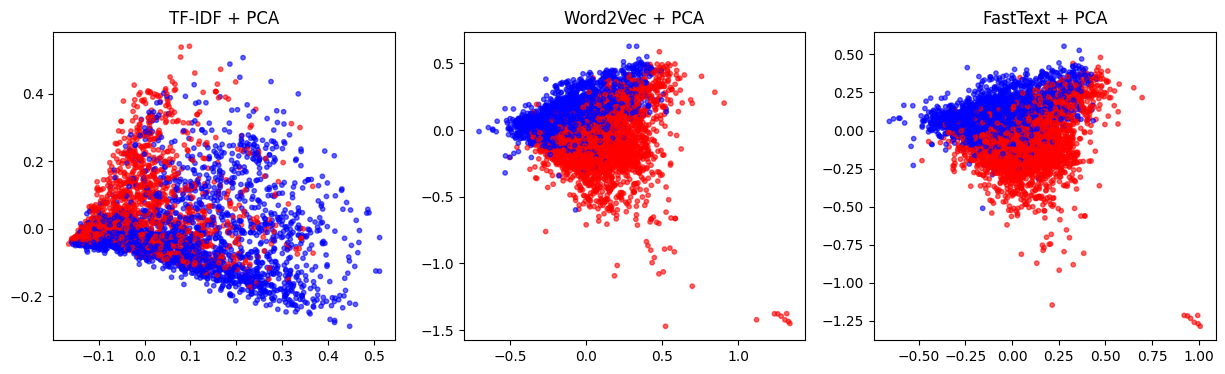

In [357]:
from sklearn.decomposition import PCA

def pca(vectors):
    pca = PCA(n_components=2, random_state=42)
    return pca.fit_transform(vectors)

tfidf_pca = pca(tfidf)
w2v_pca = pca(w2v_vectors)
ft_pca = pca(ft_vectors)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
scatter = [
    (tfidf_pca, 'TF-IDF + PCA', axes[0]),
    (w2v_pca, 'Word2Vec + PCA', axes[1]),
    (ft_pca, 'FastText + PCA', axes[2])
]

for pca_data, title, ax in scatter:
    colors = ['red' if label == 'FAKE' else 'blue' for label in df_pr['label']]
    ax.scatter(pca_data[:, 0], pca_data[:, 1], c=colors, alpha=0.6, s=10)
    ax.set_title(title)

plt.show()


Выбираем FastText потому что визуально он лучше отделяет классы, потому что векторы менее разбросаны чем у Word2Vec. TF-IDF показал себя хуже всех, видим значительное смешение классов

# Classification

## Split the dataset, choose relevant metrics for the task.

In [359]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import torch.nn as nn
import torch.optim as optim

In [364]:
le = LabelEncoder()
y = le.fit_transform(df_pr['label'])
X = w2v_vectors

In [365]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [366]:
from sklearn.metrics import accuracy_score, f1_score

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_val_pred = lr.predict(X_val)
print(accuracy_score(y_test, y_pred_lr))
print(f1_score(y_test, y_pred_lr))

0.9193277310924369
0.9185059422750425


In [367]:
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        FAKE       0.92      0.92      0.92       598
        REAL       0.92      0.92      0.92       592

    accuracy                           0.92      1190
   macro avg       0.92      0.92      0.92      1190
weighted avg       0.92      0.92      0.92      1190



Модель правильно классифицирует 91% новостей, для фейковых, из предсказанных, 91 действительно фейковые, но при этом модель находит только 92% всех фейковых новостей. Наоборот с настоящими новостями - 92 для действительно настоящих и 91 процент новостей модель находит. Таким образом, делаем вывод, что модель хорошо сбалансирована и хорошо работает на обоих класах

In [368]:
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
y_test_tensor = torch.FloatTensor(y_test)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.LongTensor(y_val).unsqueeze(1)

In [369]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

In [370]:
class BinaryMLP(nn.Module):
    def __init__(self, input_size):
        super(BinaryMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

model = BinaryMLP(X.shape[1])
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [371]:
num_epochs = 200

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')

    for batch_idx, (inputs, labels) in enumerate(train_pbar):
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        train_pbar.set_postfix({'loss': running_loss/(batch_idx+1)})

    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}')

Epoch 1/200: 100%|██████████| 28/28 [00:00<00:00, 280.56it/s, loss=0.62]


Epoch 1/200, Loss: 0.6205


Epoch 2/200: 100%|██████████| 28/28 [00:00<00:00, 353.03it/s, loss=0.264]


Epoch 2/200, Loss: 0.2639


Epoch 3/200: 100%|██████████| 28/28 [00:00<00:00, 336.82it/s, loss=0.203]


...

Epoch 198/200, Loss: 0.0000


Epoch 199/200: 100%|██████████| 28/28 [00:00<00:00, 371.95it/s, loss=1.22e-5]


Epoch 199/200, Loss: 0.0000


Epoch 200/200: 100%|██████████| 28/28 [00:00<00:00, 376.15it/s, loss=1.19e-5]

Epoch 200/200, Loss: 0.0000


In [372]:
# Evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    test_pbar = tqdm(val_loader, desc='Testing')
    for inputs, labels in test_pbar:
        outputs = model(inputs)
        preds = (outputs >= 0.5).int()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Flatten lists
all_preds = [p[0] for p in all_preds]

print(classification_report(all_labels, all_preds,
                           target_names=['negative', 'positive']))

Testing: 100%|██████████| 10/10 [00:00<00:00, 1401.14it/s]

              precision    recall  f1-score   support

    negative       0.93      0.93      0.93       598
    positive       0.93      0.93      0.93       592

    accuracy                           0.93      1190
   macro avg       0.93      0.93      0.93      1190
weighted avg       0.93      0.93      0.93      1190



Нейросеть лучше чем baseline, модель хорошо обобщает, несмотря на маленький лосс, так как тестовые метрики высокие, также хорошо, что классы сбалансированы, нет скоса к определенному классу

In [373]:
torch.save(model.state_dict(), 'model_lab_1.1.pth')

In [374]:
random.seed(42)
samples_idx = random.sample(range(len(X_test_tensor)), 10)

print("Model predictions examples:")
print("ID  |  True | Predicted | P(FAKE) | Correct")

for idx in samples_idx:
    true_label = 'FAKE' if y_test[idx] == 1 else 'REAL'

    with torch.no_grad():
        prob = model(X_test_tensor[idx].unsqueeze(0)).item()
        pred_label = 'FAKE' if prob > 0.5 else 'REAL'

    correct = 'Yes' if true_label == pred_label else 'No'
    print(f"{idx:3} | {true_label:5} | {pred_label:9} | {prob:.3f}   | {correct}")

Model predictions examples:
ID  |  True | Predicted | P(FAKE) | Correct
228 | FAKE  | FAKE      | 1.000   | Yes
 51 | FAKE  | FAKE      | 1.000   | Yes
563 | FAKE  | FAKE      | 1.000   | Yes
501 | FAKE  | FAKE      | 1.000   | Yes
457 | REAL  | REAL      | 0.000   | Yes
285 | FAKE  | FAKE      | 1.000   | Yes
209 | FAKE  | FAKE      | 1.000   | Yes
1116 | REAL  | REAL      | 0.000   | Yes
178 | FAKE  | FAKE      | 1.000   | Yes
864 | FAKE  | FAKE      | 1.000   | Yes


Базовая модель работала достаточно хорошо - 0.91, настоящая работает 0.93 - результат получилось улучшить. Модель точная и сбалансированная, имеет хорошее обобщение. FastText был выбран как метод векторизации, но можно было использовать и W2vec с практически такой же эффективностью. Архитектура получилась с 5 полносвязными слоями, использовались dropout для регуляризации.
Таким образом, модель может использоваться для автоматической фильтрации фейковых новостей. Возможно, если встраивать ее в некоторый сервис для этого, нужно будет добавить запоминание последних новостей, и чем чаще новости на одну тему попадаются, тем более правдоподобными они должны быть( фейковые новости быстро теряют популярность и про них меньше пишут). Стоит добавить, что модель слишком уверена, для улучшения можно добавить более сложные эмбеддинги или взять больше данных для обучения.